The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


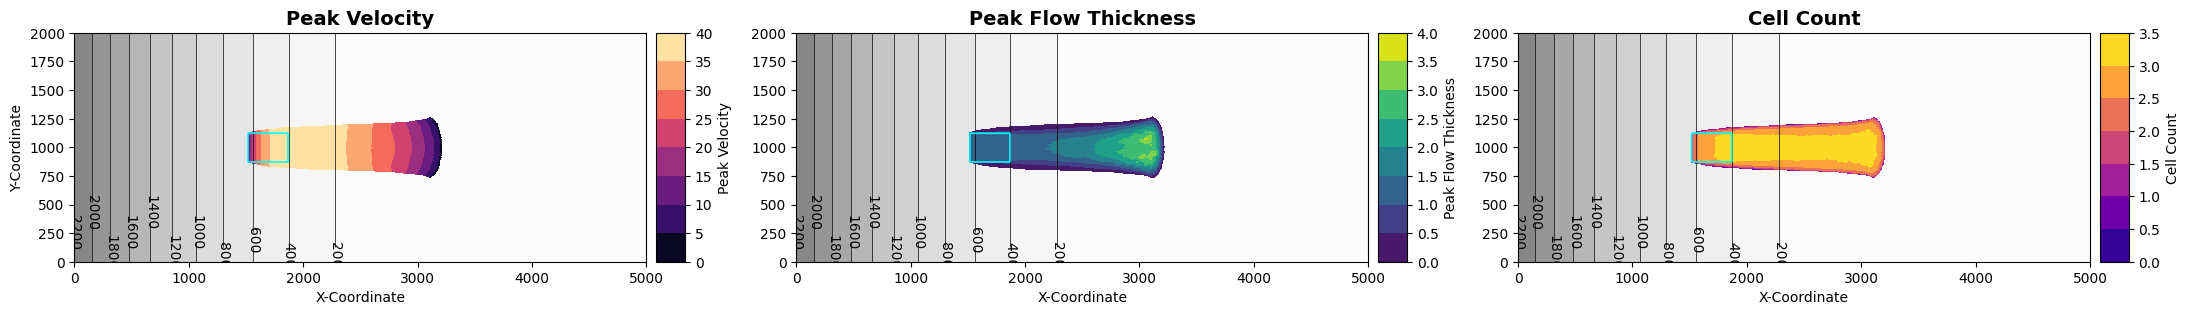

In [2]:
# kernel restart is needed after maturin develop
# kernel must be stopped for maturin develop to work
%load_ext autoreload
%autoreload 2
import avalanchers
import matplotlib.pyplot as plt

# simulation output can't be displayed in the notebook yet, only in python scripts.

# create and run a simulation with the default settings and the avaParabola DEM and defined release areas

sim = avalanchers.PySimulation.new()
sim.create_example("data/avaframe/avaParabola.png")
sim.run()
avalanchers.plot_overview(sim);

Max particle cell count:  2085


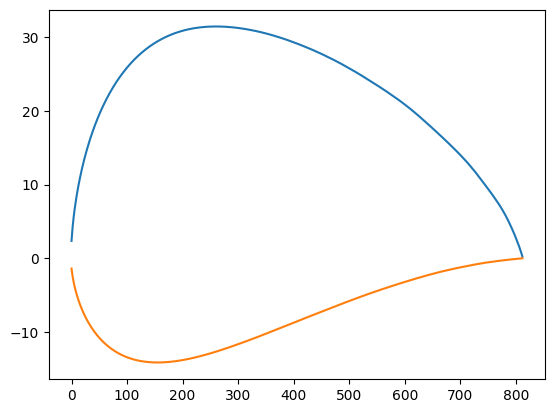

In [3]:

print("Max particle cell count: ", sim.cell_count.max())
# plot the velocity in x and z direction for all timesteps for a randomly tracked particle
plt.plot(sim.timestep_data.velocity[:, 0])
plt.plot(sim.timestep_data.velocity[:, 2])

In [ ]:
# 3d plots
import avalanchers

sim = avalanchers.PySimulation.new()
sim.create_example("data/avaframe/avaMal.png")
sim.run()

# this must be called before the first 3d plot
await avalanchers.setup_jupyter_3d()
avalanchers.plot3d(sim, "peak_velocity")


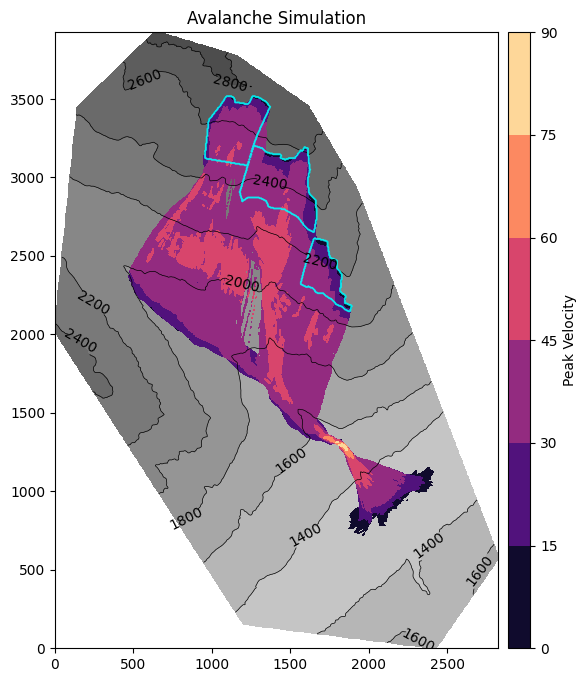

In [6]:
# 2d plots
import avalanchers

sim = avalanchers.PySimulation.new()
sim.create_example("data/avaframe/avaMal.png")
sim.run()

fig, ax = avalanchers.plot2d(sim, "peak_velocity")

In [ ]:
# Flow-Py paper example of Vals and Gries. This will take a few seconds
import avalanchers

settings = {
    "dem_path": f"data/vals/PAR6_Vals_Gries_dtm_10_utm32n_bil_.tif",
    "release_areas_path": f"data/vals/release.tif",   
}
sim = avalanchers.PySimulation.new()
sim.create(settings)

sim.run()

await avalanchers.setup_jupyter_3d()
avalanchers.plot3d(sim, "peak_velocity")

GENERAL [Loader Message (0x0)]
	windows_read_data_files_in_registry: Registry lookup failed to get layer manifest files.
	objects: (type: INSTANCE, hndl: 0x1b81f819e90, name: ?)


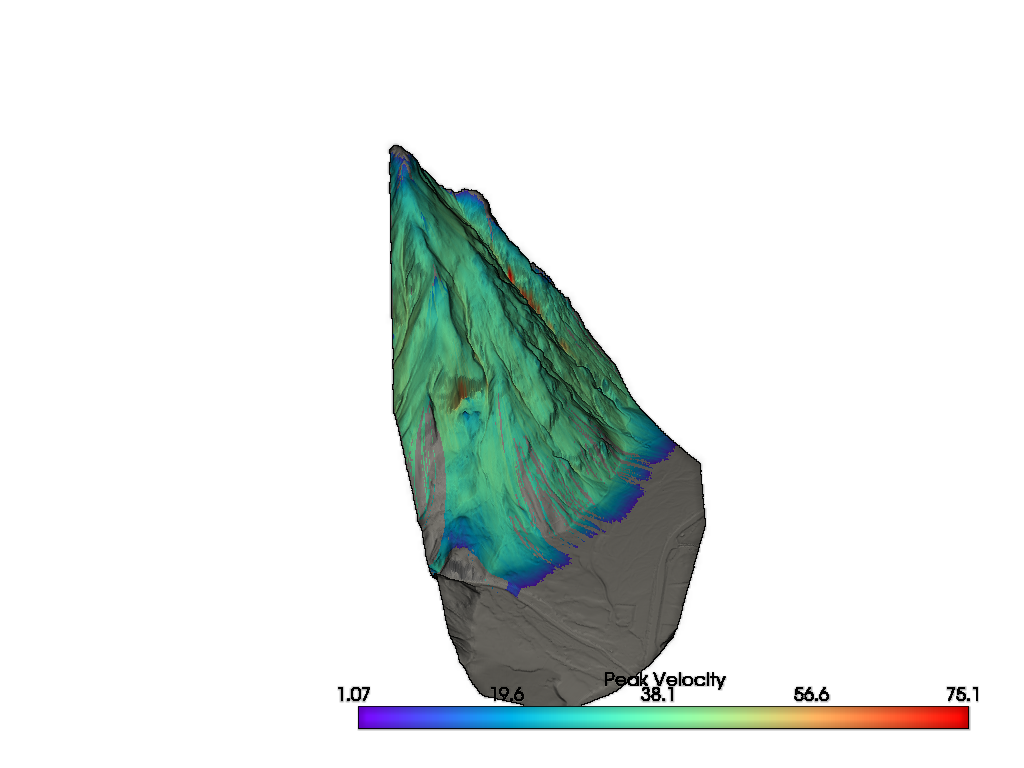

In [ ]:
# default settings with calculated release areas
import avalanchers
settings = {
    "dem_path": f"data/avaframe/avaKot.png",  
    "max_steps": 3000,
    "sim_model": 0,
    "friction_model": 1,
    "density": 200.0,
    "slab_thickness": .50,
    "friction_coefficient": 0.155,
    "drag_coefficient": 4000.0,
    "cfl": 0.5,
    "min_slope_angle": 28.0,
    "max_slope_angle": 60.0,
    "release_min_elevation": 1500.0,
    "velocity_threshold": 1e-6,
    "roughness_threshold": 0.01,
}
sim = avalanchers.PySimulation.new()
sim.create(settings)

sim.run()

avalanchers.plot3d(sim, "peak_velocity")

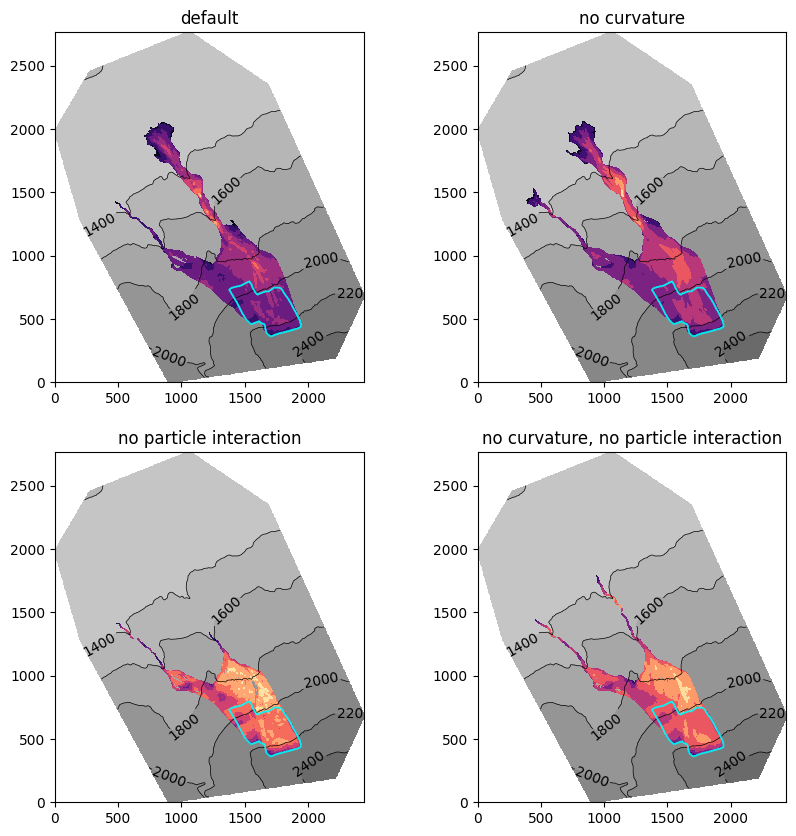

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
axes = ax.ravel()  # flatten 2x2 array of Axes -> 1D list of Axes
titles = ["default", "no curvature", "no particle interaction", "no curvature, no particle interaction"]
for i, flags in enumerate([
    (True, True, True, True),
    (False, True, True, True),
    (True, False, True, True),
    (False, False, True, True),
    (True, True, False, True),
][:4]):
    settings = {
        "dem_path": "data/avaframe/avaWog.png",
        "release_areas_path": "data/avaframe/avaWogreleaseTexture.png",
        "friction_coefficient": 0.4,
        "drag_coefficient": 2000.0,
        "enable_curvature": flags[0],
        "enable_particle_interaction": flags[1],
        "enable_earth_pressure_coefficient": flags[2],
        "enable_entrainment": flags[3],
    }

    sim = avalanchers.PySimulation.new()
    sim.create(settings)
    sim.run()

    ax, surf = avalanchers.ax2d(axes[i], sim, "peak_velocity")
    ax.set_title(titles[i])

## ISeeSnow Example VoellmyIdealized


GENERAL [Loader Message (0x0)]
	windows_read_data_files_in_registry: Registry lookup failed to get layer manifest files.
	objects: (type: INSTANCE, hndl: 0x1b81f821cf0, name: ?)


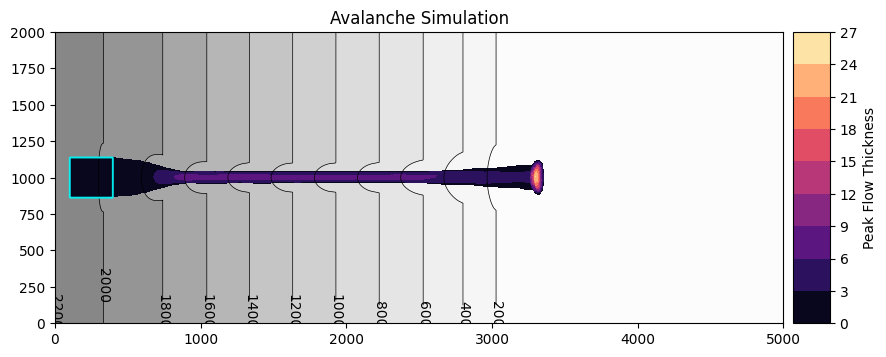

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Avalanche Simulation'}>)

In [ ]:
# default settings with calculated release areas
import avalanchers
settings = {
    "dem_path": f"data/avaframe/avaHockeyChannel.png",  
    "release_areas_path": f"data/avaframe/avaHockeyChannelreleaseTexture.png",  
    "max_steps": 3000,
    "sim_model": 0,
    "friction_model": 1,
    "density": 200.0,
    "slab_thickness": 1.50,
    "friction_coefficient": 0.4,
    "drag_coefficient": 2000.0,
    "cfl": 0.5,
    "min_slope_angle": 28.0,
    "max_slope_angle": 60.0,
    "release_min_elevation": 1500.0,
    "velocity_threshold": 1e-6,
    "roughness_threshold": 0.01,
}
sim = avalanchers.PySimulation.new()
sim.create(settings)

sim.run()

avalanchers.plot2d(sim, "peak_flow_thickness")

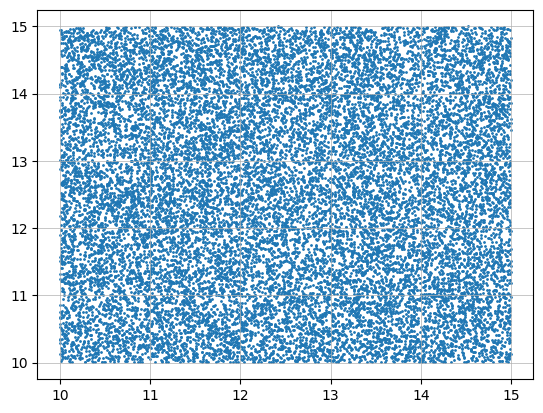

In [20]:
import avalanchers
import numpy as np
import matplotlib.pyplot as plt

dem = np.ones((6, 6))
cell_size = 5.0
sim = avalanchers.PySimulation.new()
sim.create({
    "released_particles_per_cell": 20000,
})
dem_data = np.ascontiguousarray(dem, dtype=np.float32)
sim.set_dem(
    dem_data,
    cell_size,
    0.0,
    dem_data.shape[0] * cell_size,
    0.0,
    dem_data.shape[1] * cell_size,
    1.0,
)

release_areas = np.zeros_like(dem)
release_areas[2, 2] = 1.0
release_areas_data = np.ascontiguousarray(release_areas, dtype=np.float32)
sim.set_release_areas(release_areas_data)
sim.prepare()
positions = sim.positions
plt.scatter(positions[:, 0], positions[:, 1], s=1)
plt.grid(True, which='major', linestyle='-', linewidth=0.5)

Execution time without plotting: 2.41 seconds
Jupyter detected: Launching PyVista Trame server...


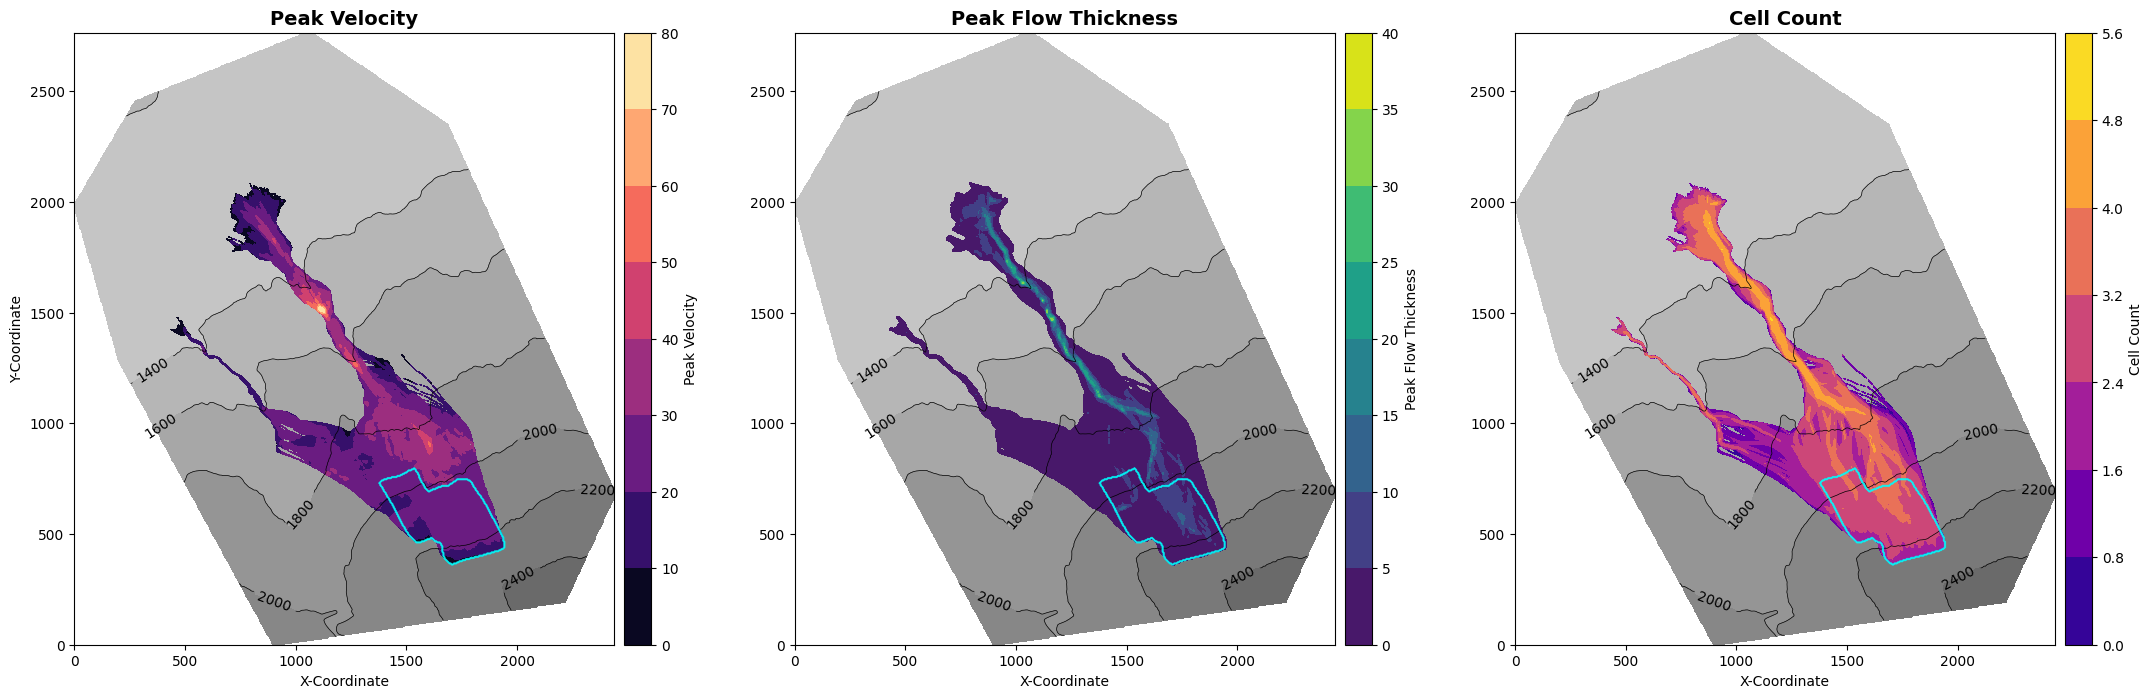

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Avalanche Simulation'}>)

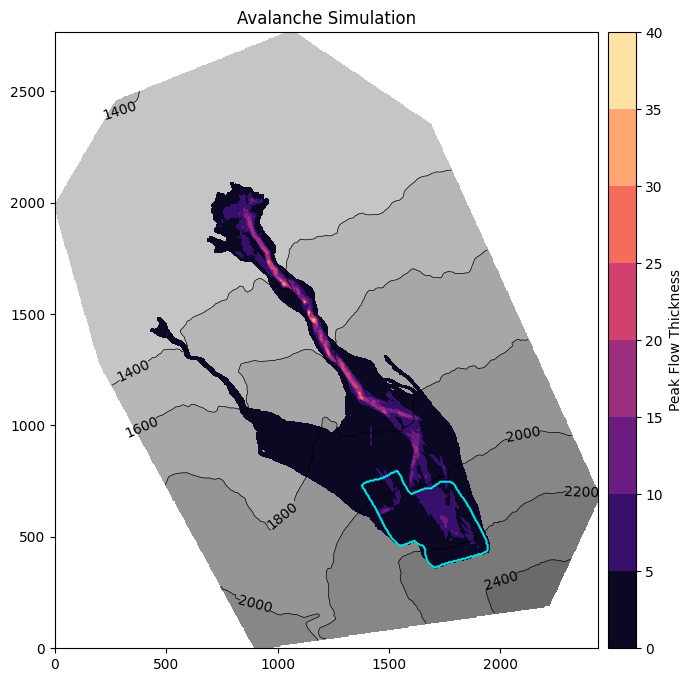

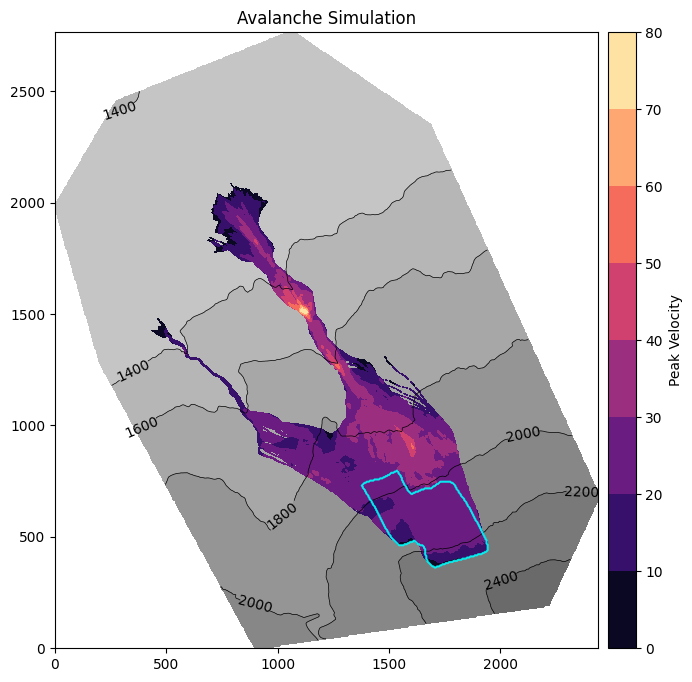

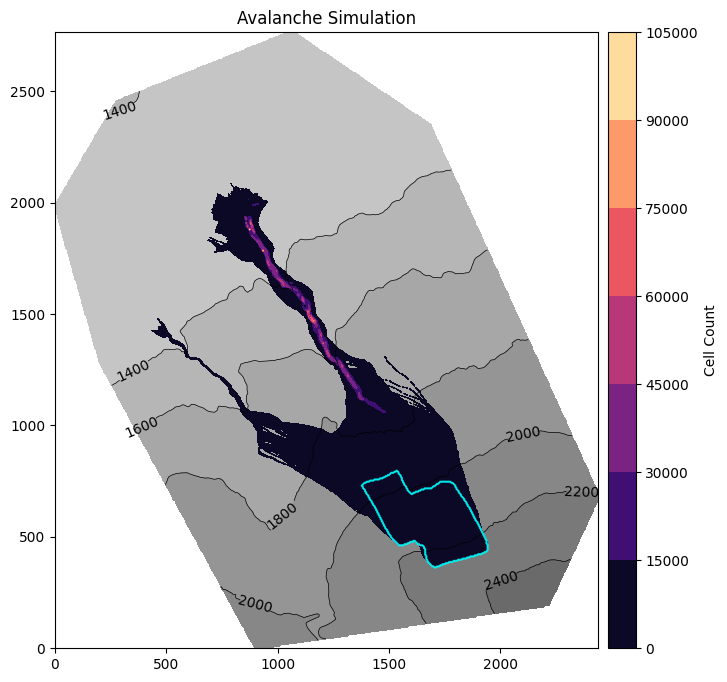

In [9]:
import time
import avalanchers

start = time.time()


example_case = "avaWog"
# example_case = "avaKot"
# example_case = "avaInclinedPlane"
# example_case = "avaFlatPlane"
# example_case = "avaHockeyChannel"

settings = {
    # mandatory: path to the DEM, currently only custom encoded png files are supported
    # optional, if not provided, a simple algorithm will be used to determine release areas based on the DEM
    "dem_path": f"data/avaframe/{example_case}.png",
    "release_areas_path": f"data/avaframe/{example_case}releaseTexture.png",   
    # "dem_path": f"data/stubai/10DTM_pilotStubai.tif", 
    # "release_areas_path": f"data/stubai/stubai_release_areas.png",
    # "dem_path": f"data/vals/PAR6_Vals_Gries_dtm_10_utm32n_bil_.tif",
    # "release_areas_path": f"data/vals/release.tif",   
    
    "max_steps": 5000,

    "sim_model": 0,
    "released_particles_per_cell": 4,
    "friction_model": 1,
    "density": 200.0,
    "slab_thickness": 1.5,
    "friction_coefficient": 0.4,
    "drag_coefficient": 2000.0,
    "cfl": 0.5,
    "min_slope_angle": 28.0,
    "max_slope_angle": 50.0,
    "release_min_elevation": 1500.0,
    "velocity_threshold": 0.1,
    "roughness_threshold": 0.01,
}
sim = avalanchers.PySimulation.new()
sim.create(settings)

# or easier for examples
# sim.create_example("data/avaframe/avaMal.png")
sim.run()

end = time.time()

print(f"Execution time without plotting: {end - start:.2f} seconds")


# avalanchers.plot3d(sim, "dem")

await avalanchers.setup_jupyter_3d()
# avalanchers.plot3d(sim, "peak_flow_thickness")
# avalanchers.plot3d(sim, "peak_velocity", True)
# avalanchers.plot3d(sim, "cell_count")
avalanchers.plot_overview(sim)

avalanchers.plot2d(sim, "peak_flow_thickness")
avalanchers.plot2d(sim, "peak_velocity")
avalanchers.plot2d(sim, "cell_count")
# avalanchers.plot2d(sim, "normals_x")
# avalanchers.plot2d(sim, "max_velocity")
